In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#Load data
df = pd.read_csv("../data/q2_customers.csv")

#Scale features 
scaler = StandardScaler()
features = ['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased']
scaled_data = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)
print("Scaled Data Preview:")
print(scaled_df.head())


Scaled Data Preview:
        age  annual_spend  visits_per_month  basket_size  \
0 -0.725219     -0.176150          0.110166    -0.265011   
1 -1.488460     -1.046826          0.486157    -0.980466   
2  0.176795      0.267337         -0.453822    -0.236851   
3 -0.725219     -1.012309          0.298161    -0.827783   
4 -1.488460     -1.034488          1.426136    -1.005986   

   days_since_last_visit  num_categories_purchased  
0              -0.089951                  0.550952  
1              -0.835176                 -0.680685  
2              -0.674046                 -0.270139  
3              -0.996306                 -1.091230  
4              -0.653905                 -1.501776  


Interpretation: Scaling helps normalize values which are on different scales, some can be in tens of thousands and some would be in single integers. In order for the numbers larger in value not dominate the distance calculation. Scaling transforms all features such that all features have a mean of 0 and Standard deviation of 1, ensuring each feature contributes equally to the clustering process. 

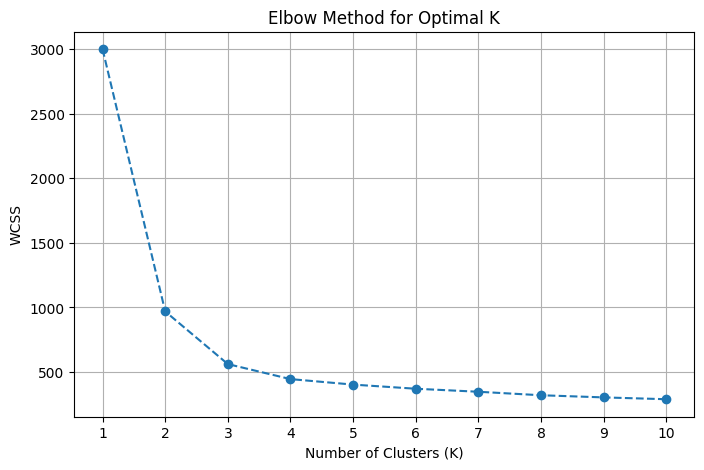

In [14]:
#Choosing K- Elbow Method 
wcss = []
K_range = range(1,11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

#Plotting the elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('elbow_plot.png')
plt.show()


Interpretation and K choosing reason: The optimal number of K = 3 since right upto 3, WCSS values drop sharply and after 3,the drop in WCSS is slows down considerably(the "elbow" of the curve). 

In [15]:
#K-Means Clustering with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_df)

#Printing cluster centers
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
print("Cluster Centroids:")
print(centroids)


Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


Interpretation of cluster profiles:
Cluster 0: "Young budget frequenters": Younger customers with a low annual spend but the highest visit in a month, representing high engagement and low ticket segment.
Cluster 1:"High-value lapsed VIPs": This group contains older customers with average age of 57, with an extremely high annual spend and large basket sizes but they visit rarely and have a high days_since_last_visit. 
Cluster 2: "Stable Middle Tier": These are middle afged customers who have a moderate spending as well as steady visit habits. They are the core and reliable customer base with average metrics all around. 


In [16]:
#Task 4: Dimensionality Reduction with PCA
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(scaled_df)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

#feature loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index = features)
print("\nPCA Feature Loadings:")
print(loadings)


Explained Variance Ratio: [0.83560354 0.05568764]

PCA Feature Loadings:
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


Interpretation:
PC1: Customer value and maturity explains approx 83.5% of the variance. It has strong positive loadings for 'age', 'annual_spend', 'basket_size', and 'num_categories_purchased', and a strong negative loading for visits_per_month
PC2: Recency and Dormancy: PC2 explains about 5.6% of the variance as it is dominated by a very high positive loading for days_since_last_visit which was 0.91. It captures how long it has been since customer's last purchase, independent of their total spending power. 


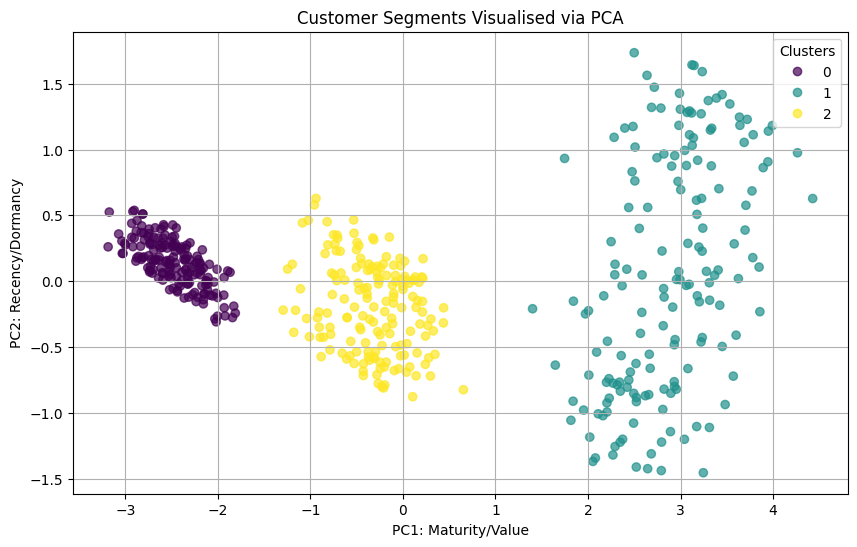

In [17]:
#Task 5: Cluster visualization in 2D PCA Space
plt.figure(figsize=(10,6))
scatter = plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.title('Customer Segments Visualised via PCA')
plt.xlabel('PC1: Maturity/Value')
plt.ylabel('PC2: Recency/Dormancy')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)
plt.savefig('pca_clusters.png')
plt.show()



